# Day 1 — MoleculeNet BBBP 데이터 탐색

이 노트북의 목적은 모델을 학습하기 전에 데이터의 구조와 품질을 이해하는 것입니다. 공식 DeepChem URL에서 BBBP 데이터를 메모리로 불러오고, 클래스 비율과 결측값을 확인한 뒤 모든 SMILES를 RDKit 분자 객체로 변환합니다.

오늘은 **모델 학습, train-test 분할, 성능 평가를 하지 않습니다.** 원본 데이터의 행도 삭제하지 않습니다.

## 1. 실행 환경과 라이브러리 확인

**입력:** 현재 Python 환경과 설치된 라이브러리입니다.  
**출력:** Python, pandas, RDKit 등 주요 라이브러리 버전과 결과 저장 폴더를 출력합니다. Matplotlib 캐시는 Git에서 제외되는 `work/` 아래에 두어 권한 문제를 예방합니다.

In [1]:
from pathlib import Path
import io
import logging
import os
import re
import sys

# 노트북을 프로젝트 루트 또는 notebooks 폴더에서 실행해도 같은 위치를 찾습니다.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
WORK_DIR = PROJECT_ROOT / "work"
RESULTS_DIR.mkdir(exist_ok=True)
WORK_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(WORK_DIR / "matplotlib-cache"))

import matplotlib
import pandas as pd
import rdkit
from IPython.display import display
from rdkit import Chem, rdBase
from rdkit.Chem import Draw

pd.set_option("display.max_colwidth", 120)

environment_versions = pd.Series(
    {
        "Python": sys.version.split()[0],
        "pandas": pd.__version__,
        "RDKit": rdkit.__version__,
        "Matplotlib": matplotlib.__version__,
    },
    name="version",
)
display(environment_versions.to_frame())
print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"결과 저장 폴더: {RESULTS_DIR}")

,version
Python,3.12.13
pandas,3.0.5
RDKit,2026.03.5
Matplotlib,3.11.1


프로젝트 루트: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp
결과 저장 폴더: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results


## 2. 공식 BBBP 데이터 불러오기

**입력:** DeepChem의 공식 BBBP 로더가 사용하는 공개 CSV URL입니다.  
**출력:** `df`라는 pandas DataFrame과 앞부분 5행을 출력합니다. 원본 CSV는 저장소에 저장하지 않고 실행할 때 메모리로만 읽습니다.

- DeepChem loader: <https://github.com/deepchem/deepchem/blob/master/deepchem/molnet/load_function/bbbp_datasets.py>
- 원 데이터 논문: Martins et al. (2012), DOI: <https://doi.org/10.1021/ci300124c>

공식 페이지에서 데이터 자체의 명확한 재배포 라이선스를 확인하기 어려우므로 원본 파일은 Git에 포함하지 않습니다.

In [2]:
DATA_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"

df = pd.read_csv(DATA_URL)
print("공식 URL에서 BBBP 데이터를 불러왔습니다.")
display(df.head())

공식 URL에서 BBBP 데이터를 불러왔습니다.


,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)[C@@H](N4C3=O)C(O)=O


## 3. 데이터 크기, 열 이름과 자료형 확인

**입력:** 방금 불러온 `df`입니다.  
**출력:** 전체 행·열 수, 열 이름, 각 열의 자료형을 출력합니다. `p_np`는 예측할 정답으로 1은 BBB+, 0은 BBB−를 뜻합니다.

In [3]:
print(f"데이터 크기: {df.shape[0]:,}행 × {df.shape[1]}열")
print(f"열 이름: {df.columns.tolist()}")
display(df.dtypes.rename("dtype").to_frame())

데이터 크기: 2,050행 × 4열
열 이름: ['num', 'name', 'p_np', 'smiles']


,dtype
num,int64
name,str
p_np,int64
smiles,str


## 4. BBB+와 BBB− 비율 확인

**입력:** 정답 열 `p_np`입니다.  
**출력:** BBB−(0)와 BBB+(1)의 개수와 전체에서 차지하는 백분율을 표로 출력합니다. 이 비율은 이후 stratified split이 필요한 이유를 보여줍니다.

In [4]:
class_summary = (
    df["p_np"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("label")
    .reset_index(name="count")
)
class_summary["class"] = class_summary["label"].map({0: "BBB-", 1: "BBB+"})
class_summary["percent"] = (class_summary["count"] / len(df) * 100).round(2)
class_summary = class_summary[["label", "class", "count", "percent"]]
display(class_summary)

,label,class,count,percent
0,0,BBB-,483,23.56
1,1,BBB+,1567,76.44


## 5. 결측값 확인

**입력:** DataFrame의 모든 열입니다.  
**출력:** 열별 결측값 개수와 비율을 표로 출력합니다. 결측값이 발견되더라도 이 단계에서는 행을 삭제하지 않습니다.

In [5]:
missing_summary = pd.DataFrame(
    {
        "missing_count": df.isna().sum(),
        "missing_percent": (df.isna().mean() * 100).round(2),
    }
)
display(missing_summary)
print(f"전체 결측값 수: {int(df.isna().sum().sum())}")

,missing_count,missing_percent
num,0,0.0
name,0,0.0
p_np,0,0.0
smiles,0,0.0


전체 결측값 수: 0


## 6. 모든 SMILES를 RDKit 분자 객체로 변환

**입력:** 각 행의 `smiles` 문자열입니다.  
**출력:** 원본 2,050행을 그대로 유지한 `exploration_df`에 `mol`, `parse_ok`, `parse_error` 열을 추가하고 성공·실패 개수를 출력합니다.

RDKit이 분자를 만들지 못하면 오류 로그를 해당 행의 `parse_error`에 저장합니다. 오류를 화면에서 단순히 숨기지 않고 구조화된 표로 남기기 위한 처리입니다.

In [6]:
rdBase.LogToPythonLogger()
rdkit_logger = logging.getLogger("rdkit")
rdkit_logger.setLevel(logging.ERROR)
original_handlers = rdkit_logger.handlers[:]
for existing_handler in original_handlers:
    rdkit_logger.removeHandler(existing_handler)

def parse_smiles_with_reason(smiles):
    """SMILES를 분자로 바꾸고, 실패하면 RDKit 오류 문장을 함께 반환합니다."""
    if pd.isna(smiles):
        return None, "SMILES 값이 비어 있습니다."

    log_stream = io.StringIO()
    log_handler = logging.StreamHandler(log_stream)
    log_handler.setLevel(logging.ERROR)
    rdkit_logger.addHandler(log_handler)

    try:
        mol = Chem.MolFromSmiles(str(smiles))
    except Exception as exc:
        mol = None
        log_stream.write(f"{type(exc).__name__}: {exc}")
    finally:
        rdkit_logger.removeHandler(log_handler)

    cleaned_lines = []
    for line in log_stream.getvalue().splitlines():
        cleaned_line = re.sub(r"^\[\d{2}:\d{2}:\d{2}\]\s*", "", line.strip())
        if cleaned_line:
            cleaned_lines.append(cleaned_line)

    error_message = " | ".join(cleaned_lines)
    if mol is None and not error_message:
        error_message = "RDKit이 분자 객체를 반환하지 않았습니다."
    return mol, error_message

parse_results = df["smiles"].map(parse_smiles_with_reason)

# 원본 df를 복사한 뒤 결과 열만 추가하며 어떤 행도 삭제하지 않습니다.
exploration_df = df.copy()
exploration_df["mol"] = parse_results.map(lambda result: result[0])
exploration_df["parse_error"] = parse_results.map(lambda result: result[1])
exploration_df["parse_ok"] = exploration_df["mol"].notna()

for original_handler in original_handlers:
    rdkit_logger.addHandler(original_handler)

parse_counts = exploration_df["parse_ok"].value_counts().rename(index={True: "성공", False: "실패"})
display(parse_counts.rename("count").to_frame())
print(f"원본 행 수 유지 여부: {len(exploration_df) == len(df)}")

,count
parse_ok,
성공,2039
실패,11


원본 행 수 유지 여부: True


## 7. 파싱 실패 SMILES 별도 표

**입력:** `parse_ok`가 False인 행과 RDKit 오류 문장입니다.  
**출력:** 실패한 행을 하나도 생략하지 않은 표를 출력하고 `results/day1_failed_smiles.csv`에 저장합니다. `atom # 숫자`만 다른 같은 종류의 오류는 묶어서 원인 요약도 보여줍니다.

In [7]:
failed_smiles = exploration_df.loc[
    ~exploration_df["parse_ok"],
    ["num", "name", "p_np", "smiles", "parse_error"],
].copy()
failed_smiles["class"] = failed_smiles["p_np"].map({0: "BBB-", 1: "BBB+"})
failed_smiles = failed_smiles[["num", "name", "p_np", "class", "smiles", "parse_error"]]

failure_path = RESULTS_DIR / "day1_failed_smiles.csv"
failed_smiles.to_csv(failure_path, index=False, encoding="utf-8")

print(f"파싱 실패 개수: {len(failed_smiles)}")
with pd.option_context("display.max_rows", None, "display.max_colwidth", 120):
    display(failed_smiles)

reason_categories = (
    failed_smiles["parse_error"]
    .str.replace(r"atom # \d+", "atom # N", regex=True)
    .value_counts()
    .rename_axis("reason_category")
    .reset_index(name="count")
)
print("실패 원인 요약:")
display(reason_categories)
print(f"저장 위치: {failure_path}")

파싱 실패 개수: 11


,num,name,p_np,class,smiles,parse_error
59,60,15,1,BBB+,O=N([O-])C1=C(CN=C1NCCSCc2ncccc2)Cc3ccccc3,"Explicit valence for atom # 1 N, 4, is greater than permitted"
61,62,22767,1,BBB+,c1(nc(NC(N)=[NH2])sc1)CSCCNC(=[NH]C#N)NC,"Explicit valence for atom # 6 N, 4, is greater than permitted"
391,393,ICI17148,1,BBB+,Cc1nc(sc1)\[NH]=C(\N)N,"Explicit valence for atom # 6 N, 4, is greater than permitted"
614,616,5-6,1,BBB+,s1cc(CSCCN\C(NC)=[NH]\C#N)nc1\[NH]=C(\N)N,"Explicit valence for atom # 11 N, 4, is greater than permitted"
642,644,12,0,BBB-,c1c(c(ncc1)CSCCN\C(=[NH]\C#N)NCC)Br,"Explicit valence for atom # 12 N, 4, is greater than permitted"
645,647,16,1,BBB+,n1c(csc1\[NH]=C(\N)N)c1ccccc1,"Explicit valence for atom # 5 N, 4, is greater than permitted"
646,648,17,0,BBB-,n1c(csc1\[NH]=C(\N)N)c1cccc(c1)N,"Explicit valence for atom # 5 N, 4, is greater than permitted"
647,649,18,0,BBB-,n1c(csc1\[NH]=C(\N)N)c1cccc(c1)NC(C)=O,"Explicit valence for atom # 5 N, 4, is greater than permitted"
648,650,19,0,BBB-,n1c(csc1\[NH]=C(\N)N)c1cccc(c1)N\C(NC)=[NH]\C#N,"Explicit valence for atom # 5 N, 4, is greater than permitted"
649,651,2,1,BBB+,s1cc(nc1\[NH]=C(\N)N)C,"Explicit valence for atom # 5 N, 4, is greater than permitted"


실패 원인 요약:


,reason_category,count
0,"Explicit valence for atom # N N, 4, is greater than permitted",11


저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day1_failed_smiles.csv


## 8. BBB+와 BBB− 예시 분자 시각화

**입력:** 파싱에 성공한 분자 중 BBB+와 BBB− 데이터입니다.  
**출력:** `random_state=42`로 각 클래스에서 6개씩 뽑아 2행 격자로 표시하고 `results/day1_bbb_examples.png`에 저장합니다. 시각화를 위해 표본을 뽑을 뿐 원본 행은 삭제하지 않습니다.

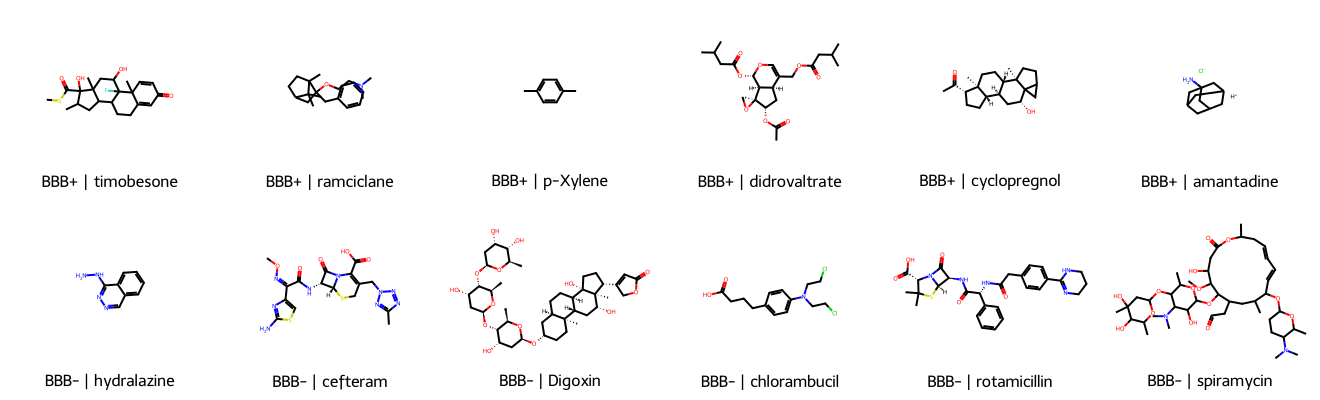

저장 위치: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day1_bbb_examples.png


In [8]:
valid_molecules = exploration_df.loc[exploration_df["parse_ok"]].copy()
bbb_plus_examples = valid_molecules.loc[valid_molecules["p_np"] == 1].sample(n=6, random_state=42)
bbb_minus_examples = valid_molecules.loc[valid_molecules["p_np"] == 0].sample(n=6, random_state=42)
example_molecules = pd.concat([bbb_plus_examples, bbb_minus_examples], ignore_index=True)

legends = []
for _, row in example_molecules.iterrows():
    molecule_name = str(row["name"])
    if len(molecule_name) > 24:
        molecule_name = molecule_name[:21] + "..."
    class_name = "BBB+" if row["p_np"] == 1 else "BBB-"
    legends.append(f"{class_name} | {molecule_name}")

molecule_grid = Draw.MolsToGridImage(
    example_molecules["mol"].tolist(),
    molsPerRow=6,
    subImgSize=(220, 200),
    legends=legends,
    returnPNG=False,
)
example_image_path = RESULTS_DIR / "day1_bbb_examples.png"
molecule_grid.save(example_image_path)
display(molecule_grid)
print(f"저장 위치: {example_image_path}")

## 9. Day 1 요약과 무결성 검사

**입력:** 앞에서 계산한 데이터 크기, 클래스 수, 결측값 수와 파싱 결과입니다.  
**출력:** Day 1 핵심 수치를 표로 출력하여 `results/day1_data_summary.csv`에 저장하고, 행 보존 및 결과 파일 생성을 자동으로 검사합니다.

In [9]:
class_counts = df["p_np"].value_counts()
day1_summary = pd.DataFrame(
    [
        {"item": "total_rows", "value": str(len(df))},
        {"item": "total_columns", "value": str(df.shape[1])},
        {"item": "BBB+_count", "value": str(int(class_counts.get(1, 0)))},
        {"item": "BBB+_percent", "value": f"{class_counts.get(1, 0) / len(df) * 100:.2f}"},
        {"item": "BBB-_count", "value": str(int(class_counts.get(0, 0)))},
        {"item": "BBB-_percent", "value": f"{class_counts.get(0, 0) / len(df) * 100:.2f}"},
        {"item": "missing_values", "value": str(int(df.isna().sum().sum()))},
        {"item": "parse_success", "value": str(int(exploration_df["parse_ok"].sum()))},
        {"item": "parse_failure", "value": str(int((~exploration_df["parse_ok"]).sum()))},
    ]
)
summary_path = RESULTS_DIR / "day1_data_summary.csv"
day1_summary.to_csv(summary_path, index=False, encoding="utf-8")
display(day1_summary)

assert len(exploration_df) == len(df), "SMILES 파싱 중 원본 행 수가 달라졌습니다."
assert exploration_df["parse_ok"].sum() + len(failed_smiles) == len(df), "파싱 성공/실패 합계가 전체 행 수와 다릅니다."
assert failure_path.exists(), "파싱 실패 CSV가 생성되지 않았습니다."
assert example_image_path.exists(), "예시 분자 이미지가 생성되지 않았습니다."
assert summary_path.exists(), "Day 1 요약 CSV가 생성되지 않았습니다."
assert not (PROJECT_ROOT / "BBBP.csv").exists(), "원본 BBBP.csv가 저장소 루트에 저장되었습니다."

print("Day 1 검증 통과: 원본 행을 유지했고 모든 결과 파일이 생성되었습니다.")
print("모델 학습은 수행하지 않았습니다.")

,item,value
0,total_rows,2050
1,total_columns,4
2,BBB+_count,1567
3,BBB+_percent,76.44
4,BBB-_count,483
5,BBB-_percent,23.56
6,missing_values,0
7,parse_success,2039
8,parse_failure,11


Day 1 검증 통과: 원본 행을 유지했고 모든 결과 파일이 생성되었습니다.
모델 학습은 수행하지 않았습니다.
